# Классификация -> превышает ли SI значение 8

В этом ноутбуке решается задача бинарной классификации.

Целевая переменная показывает, превышает ли показатель `SI` значение 8:

- `0` -> `SI <= 8`
- `1` -> `SI > 8`

Цель эксперимента -> проверить, можно ли по молекулярным дескрипторам определить соединения,
у которых индекс селективности превышает пороговое значение `8`.

# Импорты

In [56]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt

# Разделение данных и оценка качества
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    load_coursework_dataset,
)

# Конфигурация проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_SI,
    TEST_SIZE,
)

# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_si_above_threshold_target,
    preprocess_features,
)

# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import (
    get_classification_models,
)

# Запуск экспериментов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_classification_experiment,
)

# Визуализация результатов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_classification_results,
)

# Отключение предупреждений
warnings.filterwarnings("ignore")

## Загрузка данных

Загрузим исходный датасет с молекулярными дескрипторами и целевыми показателями.

In [57]:
df = load_coursework_dataset()

df.shape

(1001, 214)

## Формирование признаков и целевой переменной

Сформируем матрицу признаков `X` и бинарную целевую переменную `y`.

В этой задаче положительный класс соответствует соединениям, у которых:
```
SI > 8
Такая постановка отличается от классификации относительно медианы, потому что порог 8
является фиксированным прикладным критерием, а не статистической границей выборки.
```

In [58]:
X = build_features(df)

y = build_si_above_threshold_target(

    dataframe=df,

    threshold=8.0,

)

print(f"Размер исходной матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Пороговое значение {TARGET_SI}: 8.0000")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Пороговое значение SI: 8.0000


## Распределение классов

Проверим баланс классов.

Так как порог `SI > 8` не основан на медиане, распределение классов может быть заметно несбалансированным.
Это важно учитывать при интерпретации метрик качества.

In [59]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["share"] = class_distribution["count"] / class_distribution["count"].sum()

class_distribution

,class,count,share
0,0,644,0.643357
1,1,357,0.356643


## Предобработка признаков

Выполним очистку признакового пространства:

- удалим константные признаки
- удалим почти константные признаки
- удалим сильно коррелирующие признаки

Целевую переменную в предобработку не передаем, чтобы не допустить утечку данных.

In [60]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")
print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [61]:
# Сводка по предобработке
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Подготовка моделей классификации

Для сравнения используем несколько моделей бинарной классификации:

- DummyClassifier
- Logistic Regression
- KNN
- SVC
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

`DummyClassifier` используется как базовая модель.
Если рабочие модели не превосходят dummy-модель, значит они не находят полезных закономерностей в признаках.

In [62]:
classification_models = get_classification_models()

classification_models.keys()

dict_keys(['dummy_most_frequent', 'logistic_regression', 'knn', 'svc_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Запуск эксперимента

Запустим обучение и сравнение моделей.

Основная метрика выбора лучшей модели — `F1`, так как она учитывает баланс между:

- `precision` -> насколько точны положительные предсказания
- `recall` -> насколько полно модель находит положительный класс `SI > 8`

Дополнительно анализируем `accuracy`, `balanced_accuracy` и `ROC-AUC`.

In [63]:
si_gt_8_classification_results, si_gt_8_fitted_models = run_classification_experiment(
    X=X_clean,
    y=y,
    models=classification_models,
)

si_gt_8_classification_results["feature_set"] = "preprocessed_features"
si_gt_8_classification_results["target"] = "si_gt_8"

si_gt_8_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,extra_trees,0.585978,0.017328,800,201,0.617713,0.691542,0.670704,0.565789,0.597222,0.581081,0.743056,preprocessed_features,si_gt_8
1,svc_rbf,0.589569,0.032722,800,201,0.242198,0.661692,0.653585,0.523256,0.625000,0.569620,0.708064,preprocessed_features,si_gt_8
2,knn,0.549391,0.021781,800,201,0.046772,0.676617,0.659076,0.544304,0.597222,0.569536,0.734388,preprocessed_features,si_gt_8
3,random_forest,0.568048,0.028112,800,201,0.692128,0.701493,0.656977,0.600000,0.500000,0.545455,0.750161,preprocessed_features,si_gt_8
4,catboost,0.554991,0.023260,800,201,4.154596,0.701493,0.653908,0.603448,0.486111,0.538462,0.731966,preprocessed_features,si_gt_8
5,logistic_regression,0.554069,0.026392,800,201,0.055412,0.631841,0.624193,0.488636,0.597222,0.537500,0.678241,preprocessed_features,si_gt_8
6,hist_gradient_boosting,0.562980,0.039621,800,201,2.264820,0.681592,0.638404,0.564516,0.486111,0.522388,0.708818,preprocessed_features,si_gt_8
7,dummy_most_frequent,0.000000,0.000000,800,201,0.017008,0.641791,0.500000,0.000000,0.000000,0.000000,0.500000,preprocessed_features,si_gt_8


## Сохранение метрик

In [64]:
si_gt_8_classification_results.to_csv(
    METRICS_DIR / "classification_si_gt_8_metrics.csv",
    index=False,
)

## График сравнения моделей

Визуально сравним модели по значению `F1`.

Чем выше значение `F1`, тем лучше модель одновременно справляется
с точностью и полнотой определения класса `SI > 8`.

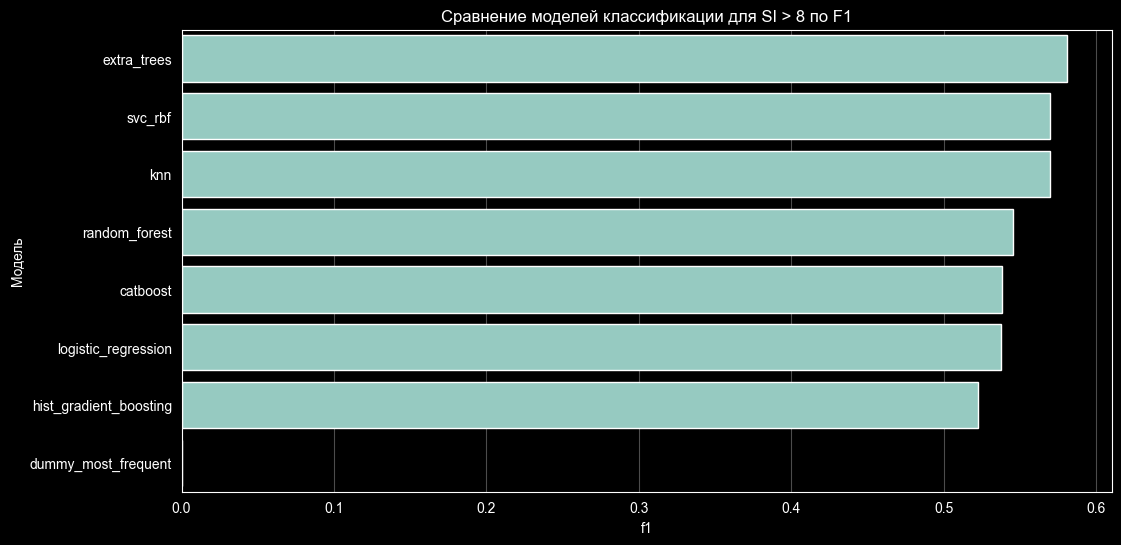

In [65]:
plot_classification_results(
    results_df=si_gt_8_classification_results,
    metric="f1",
    title="Сравнение моделей классификации для SI > 8 по F1",
)

## Выбор лучшей модели

Выберем модель с максимальным значением `F1`.

Дополнительно посмотрим:

- набор признаков
- целевую переменную
- accuracy
- balanced accuracy
- precision
- recall
- F1
- ROC-AUC

In [66]:
best_result = si_gt_8_classification_results.iloc[0]

best_result

model                          extra_trees
cv_f1_mean                        0.585978
cv_f1_std                         0.017328
train_rows                             800
test_rows                              201
fit_time_sec                      0.617713
accuracy                          0.691542
balanced_accuracy                 0.670704
precision                         0.565789
recall                            0.597222
f1                                0.581081
roc_auc                           0.743056
feature_set          preprocessed_features
target                             si_gt_8
Name: 0, dtype: object

## Вывод названия лучшей модели

In [67]:
best_model_name = best_result["model"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_result['feature_set']}")
print(f"Целевая переменная: {best_result['target']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Balanced accuracy: {best_result['balanced_accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")
print(f"F1: {best_result['f1']:.4f}")
print(f"ROC-AUC: {best_result['roc_auc']:.4f}")

Лучшая модель: extra_trees
Набор признаков: preprocessed_features
Целевая переменная: si_gt_8
Accuracy: 0.6915
Balanced accuracy: 0.6707
Precision: 0.5658
Recall: 0.5972
F1: 0.5811
ROC-AUC: 0.7431


## Предсказания лучшей модели

Повторим разбиение на train/test с теми же параметрами, которые использовались внутри эксперимента.

Так как задача классификации может иметь дисбаланс классов, используем `stratify=y`.
Это сохраняет соотношение классов в обучающей и тестовой выборках.

In [68]:
best_model = si_gt_8_fitted_models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "classification_si_gt_8_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
546,0,0
376,0,0
841,0,0
452,0,1
868,0,0


## Отчет классификации

Посмотрим `precision`, `recall` и `F1` отдельно по каждому классу.

Особое внимание уделяем классу `SI > 8`, потому что именно он соответствует соединениям
с более высоким индексом селективности.

In [69]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "SI <= 8",
            "SI > 8",
        ],
    )
)

              precision    recall  f1-score   support

     SI <= 8       0.77      0.74      0.76       129
      SI > 8       0.57      0.60      0.58        72

    accuracy                           0.69       201
   macro avg       0.67      0.67      0.67       201
weighted avg       0.70      0.69      0.69       201



## Матрица ошибок

Матрица ошибок показывает, сколько объектов каждого класса модель определила правильно и неправильно.

Для этой задачи особенно важны ошибки, при которых соединение с `SI > 8`
ошибочно относится к классу `SI <= 8`, потому что такие объекты могут быть потеряны
как потенциально перспективные.

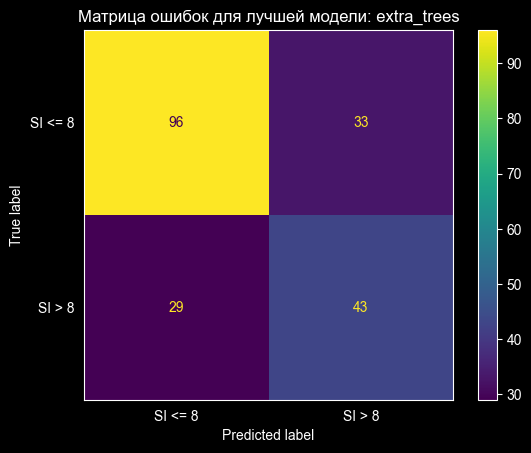

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "SI <= 8",
        "SI > 8",
    ],
)

plt.title(f"Матрица ошибок для лучшей модели: {best_model_name}")
plt.grid(False)
plt.show()

## Важность признаков

Для оценки важности признаков используем `permutation_importance`.

Этот подход подходит не только для древесных моделей, но и для моделей вроде `KNN`, `SVC`
и логистической регрессии.

Логика метода:

- берем обученную модель
- перемешиваем значения одного признака
- смотрим, насколько ухудшилось качество
- чем сильнее падает `F1`, тем важнее признак

In [71]:
permutation_result = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    scoring="f1",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X_clean.columns,
            "importance_mean": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        }
    )
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance_mean,importance_std
0,FractionCSP3,0.024798,0.007036
1,fr_bicyclic,0.020493,0.010363
2,PEOE_VSA8,0.017982,0.009621
3,PEOE_VSA7,0.017684,0.008464
4,NumRotatableBonds,0.017162,0.007682
5,NumAliphaticRings,0.015387,0.008139
6,EState_VSA5,0.013372,0.007214
7,EState_VSA8,0.012193,0.011374
8,NumAliphaticHeterocycles,0.012071,0.011138
9,MaxAbsEStateIndex,0.012051,0.006512


## График важности признаков

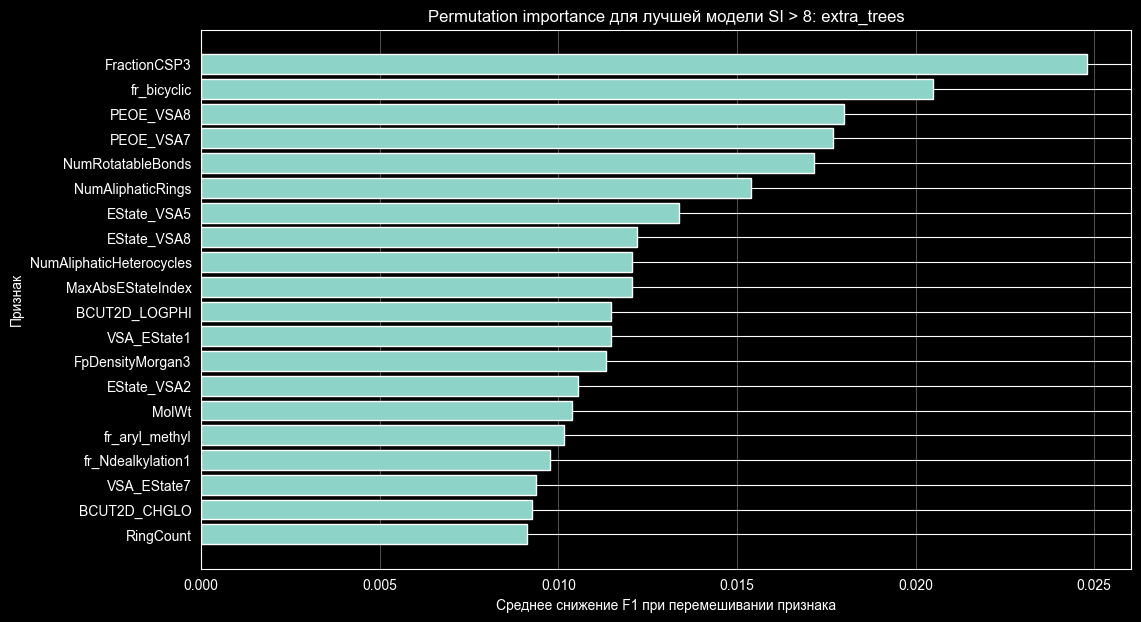

In [72]:
top_importance_df = importance_df.head(20)

plt.figure(figsize=(12, 7))
plt.barh(
    top_importance_df["feature"][::-1],
    top_importance_df["importance_mean"][::-1],
)

plt.title(f"Permutation importance для лучшей модели SI > 8: {best_model_name}")
plt.xlabel("Среднее снижение F1 при перемешивании признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Сохранение важности признаков

In [73]:
importance_df.to_csv(
    METRICS_DIR / "classification_si_gt_8_permutation_importance.csv",
    index=False,
)

## Итоговый вывод по задаче классификации SI > 8

В этом ноутбуке была решена задача бинарной классификации соединений по целевой переменной `SI > 8`.

Порог `SI = 8` был выбран как прикладной критерий отбора более перспективных соединений,
так как такие объекты имеют более высокий индекс селективности.

В отличие от разбиения по медиане, этот вариант задачи является менее сбалансированным:

- к классу `SI <= 8` относится 644 объекта
- к классу `SI > 8` относится 357 объектов.

Поэтому при оценке моделей важно учитывать не только `accuracy`, но и `balanced_accuracy`, `precision`, `recall`, `F1` и `ROC-AUC`.

Перед обучением была выполнена предобработка признаков.
Исходная матрица содержала 1001 объект и 210 признаков.
После удаления константных, почти константных и сильно коррелирующих признаков осталось 134 признака.
Всего было удалено 76 признаков: 18 константных, 15 почти константных и 43 сильно коррелирующих.
Это позволило уменьшить размерность признакового пространства и убрать признаки,
которые либо не несут полезной информации, либо дублируют другие признаки.

Для сравнения использовались несколько моделей бинарной классификации:

- `DummyClassifier`
- `Logistic Regression`
- `KNN`
- `SVC`
- `Random Forest`
- `Extra Trees`
- `HistGradientBoosting`
- `CatBoost`

Базовая модель `DummyClassifier` показала нулевое значение F1,
что подтверждает необходимость использования полноценных моделей машинного обучения.

Лучшей моделью по значению F1 стала `extra_trees`.

Итоговые метрики лучшей модели:

- `accuracy`: 0.6915
- `balanced_accuracy`: 0.6707
- `precision`: 0.5658
- `recall`: 0.5972
- `F1`: 0.5811
- `ROC-AUC`: 0.7431

По отчету классификации видно, что модель лучше распознает класс `SI <= 8`, чем класс `SI > 8`.
Для класса `SI <= 8` значение F1 составило 0.76, а для класса `SI > 8` составило 0.58.
Это ожидаемо, так как положительный класс `SI > 8` представлен в данных заметно реже.

Матрица ошибок показывает, что модель верно определила 96 объектов класса `SI <= 8` и 43 объекта класса `SI > 8`.
При этом 33 объекта с низким SI были ошибочно отнесены к классу `SI > 8`, а 29 перспективных соединений с `SI > 8` были пропущены моделью.

С практической точки зрения модель можно использовать как предварительный фильтр для поиска соединений с повышенным индексом селективности.
Однако качество определения класса `SI > 8` пока умеренное, модель находит около 60% таких соединений.
На следующих этапах стоит дополнительно настраивать порог классификации, чтобы повысить recall для класса `SI > 8`.

Анализ permutation importance показал,
что наибольший вклад в качество модели внесли признаки
`FractionCSP3`, `fr_bicyclic`, `PEOE_VSA8`, `PEOE_VSA7`,
`NumRotatableBonds`, `NumAliphaticRings`, `EState_VSA5`,
`EState_VSA8`, `NumAliphaticHeterocycles` и `MaxAbsEStateIndex`.

### Итог

Задача классификации `SI > 8` оказалась сложнее, чем классификация по медиане, из-за дисбаланса классов и более прикладного порога.
Модель `Extra Trees` смогла найти полезные закономерности в данных и заметно превзошла базовый классификатор.